## Samplets in a nutshell

**FMCA** builds a *samplet basis*: a discrete, multiresolution, locally supported basis on an
**arbitrary point cloud** $X = \{x_1,\dots,x_N\}\subset\mathbb{R}^d$ &mdash; no grid, no mesh required.

Samplets are the point-cloud analogue of wavelets. Like wavelets they are

* **orthonormal** &mdash; the transform is a change of orthonormal basis, so energy is preserved,
* **multilevel** &mdash; organised along a cluster tree, coarse to fine,
* **locally supported** &mdash; each samplet lives on one cluster,
* **vanishing moments** &mdash; they annihilate polynomials up to degree $\tilde d - 1$.

The last property is what makes them useful: on smooth data almost all coefficients are
*negligible*, and the few large ones sit exactly where the data is *not* smooth.

This notebook shows the objects; the following notebooks put them to work.

In [19]:
# the KMP setting avoids a clash between the OpenMP runtimes of FMCA and numpy
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import time
import numpy as np
import matplotlib.pyplot as plt
import FMCA

plt.rcParams.update({
    "figure.dpi": 80,
    "font.size": 11,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.constrained_layout.use": True,
})
C_DATA, C_SAMP, C_REF = "#1f4e79", "#c1121f", "#2a9d8f"

## A samplet tree on a point cloud

Everything starts from a cluster tree over the points. `FMCA.SampletTree(P, dtilde)` takes

* `P` &mdash; a `dim x N` array, **column major** (`order='F'`), one point per column,
* `dtilde` &mdash; the number of vanishing moments $\tilde d$.

The tree reorders the points; `ST.indices()` gives that permutation.

In [20]:
dim, N, dtilde = 1, 10000, 3
pts = np.array(np.linspace(0, 1, N).reshape(dim, N), order="F")

t0 = time.time()

# create the samplet tree
ST = FMCA.SampletTree(pts, dtilde) 
print(f"samplet tree construction: {time.time() - t0:.3f} s")

# the tree order: spts[:, i] is the i-th point in cluster order
spts = np.asfortranarray(pts[:, ST.indices()])

print(f"dimension                 {ST.dim()}")
print(f"points                    {ST.npts()}")
print(f"clusters in the tree      {ST.nclusters()}")
print(f"vanishing moments dtilde  {ST.dtilde()}")
print(f"scaling coefficients      {ST.nscalfs()}   (the coarse part of the basis)")

samplet tree construction: 0.042 s
dimension                 1
points                    10000
clusters in the tree      3615
vanishing moments dtilde  3
scaling coefficients      3   (the coarse part of the basis)


In [21]:
# FMCA.sampletTreeStatistics(ST, pts)

## What does a samplet look like?

The samplet transform $\Sigma$ maps data to coefficients. The basis functions themselves are
recovered by inverse transforming the unit vectors: $\sigma_j = \Sigma^{-1} e_j$.

`ST.levels()` tells us the level of every coefficient, so we can pick one samplet per level.

coefficients per level: {0: 6, 1: 6, 2: 12, 3: 24, 4: 48, 5: 96, 6: 192, 7: 384, 8: 768, 9: 1536, 10: 3792, 11: 3136}


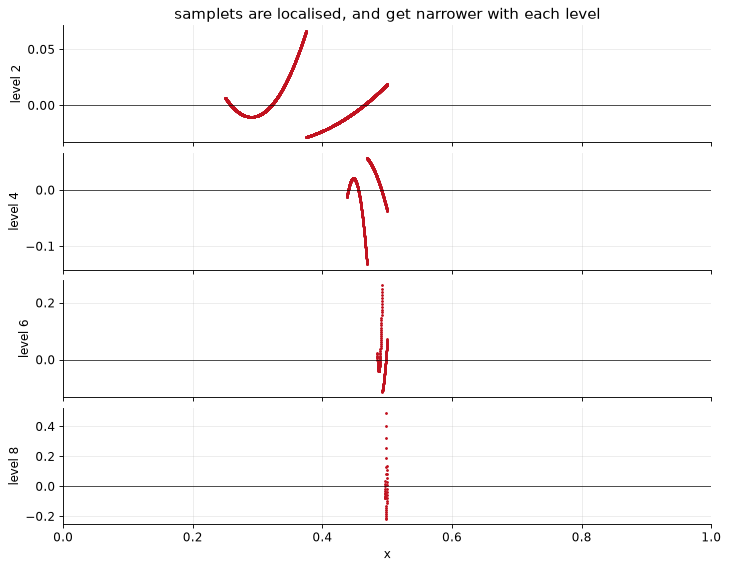

In [22]:
lvl = np.asarray(ST.levels(), dtype=int)
print("coefficients per level:",
      {int(L): int((lvl == L).sum()) for L in np.unique(lvl)})

# the support of coefficient j is the cluster it belongs to
centers = np.array([pts[0, ST.coeff2indices(j)].mean() for j in range(N)])

show_levels = [2, 4, 6, 8]
fig, axes = plt.subplots(len(show_levels), 1, figsize=(9, 7), sharex=True)
for ax, L in zip(axes, show_levels):
    # pick the samplet on level L whose support is closest to x = 0.5
    cand = np.where(lvl == L)[0]
    j = cand[np.argmin(np.abs(centers[cand] - 0.5))]
    unit = np.zeros((N, 1), order="F")
    unit[j] = 1.0
    basis = ST.inverseSampletTransform(unit).ravel()
    supp = np.abs(basis) > 1e-14
    ax.plot(spts[0, supp], basis[supp], ".", ms=3, color=C_SAMP)
    ax.axhline(0, lw=0.6, color="k")
    ax.set_ylabel(f"level {L}")
axes[0].set_title("samplets are localised, and get narrower with each level")
axes[-1].set_xlabel("x")
axes[-1].set_xlim(0, 1)
plt.show()

## Vanishing moments

A samplet with $\tilde d$ vanishing moments is orthogonal to every polynomial of degree
$< \tilde d$. So if we transform a polynomial, *all* detail coefficients must vanish &mdash;
only the first `ST.nscalfs()` scaling coefficients survive.

In [23]:
print(f"{'dtilde':>7} {'nscalfs':>9} {'deg 1':>10} {'deg 2':>10} {'deg 3':>10} {'deg 4':>10}")
for dt in (1, 2, 3, 4, 5):
    tree = FMCA.SampletTree(pts, dt)
    z = tree.toClusterOrder(np.asfortranarray(pts[0].reshape(-1, 1))).ravel()
    row = f"{dt:>7} {tree.nscalfs():>9}"
    for deg in (1, 2, 3, 4):
        c = tree.sampletTransform(np.asfortranarray((z ** deg).reshape(-1, 1)))
        row += f" {np.abs(c[tree.nscalfs():]).max():>10.1e}"
    print(row)
print("\nmax |detail coefficient| of x^deg -- machine zero exactly while deg < dtilde")

 dtilde   nscalfs      deg 1      deg 2      deg 3      deg 4
      1         1    2.5e+01    2.5e+01    2.2e+01    1.9e+01
      2         2    8.5e-15    6.4e+00    1.0e+01    1.2e+01
      3         3    7.1e-15    8.0e-15    1.3e+00    2.5e+00
      4         4    6.4e-15    4.1e-15    5.4e-15    3.3e-01
      5         5    5.6e-15    3.6e-15    6.4e-15    5.3e-15

max |detail coefficient| of x^deg -- machine zero exactly while deg < dtilde


## The transform is orthogonal, and sparse

`ST.transformationMatrix()` writes the samplet transform out as a sparse matrix $T$, so that
`T @ data == ST.sampletTransform(data)` for cluster ordered data. It has $O(N\log N)$
nonzeros and $T T^\top = I$.

In practice you never form $T$ &mdash; `sampletTransform` applies it in $O(N)$ operations.
It is shown here only to make the structure visible.

T is 10000 x 10000 with 382160 nonzeros (38.2 per row, 0.38 % dense)
|| T d - sampletTransform(d) || / || . || = 2.72e-15
|| T T^T - I ||_max                       = 9.38e-14


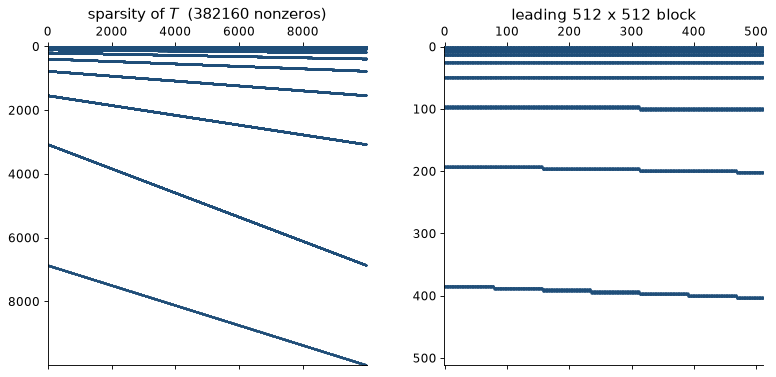

In [24]:
T = ST.transformationMatrix()
data = np.asfortranarray(np.random.rand(N, 1))

print(f"T is {T.shape[0]} x {T.shape[1]} with {T.nnz} nonzeros "
      f"({T.nnz / N:.1f} per row, {100 * T.nnz / N**2:.2f} % dense)")
print(f"|| T d - sampletTransform(d) || / || . || = "
      f"{np.linalg.norm(T @ data - ST.sampletTransform(data)) / np.linalg.norm(data):.2e}")
print(f"|| T T^T - I ||_max                       = "
      f"{np.abs((T @ T.T).toarray() - np.eye(N)).max():.2e}")

fig, ax = plt.subplots(1, 2, figsize=(10, 4.6))
ax[0].spy(T, markersize=0.15, color=C_DATA)
ax[0].set_title(f"sparsity of $T$  ({T.nnz} nonzeros)")
ax[0].grid(False)
sub = 512
ax[1].spy(T[:sub, :sub], markersize=0.8, color=C_DATA)
ax[1].set_title(f"leading {sub} x {sub} block")
ax[1].grid(False)
plt.show()

## Samplets on a 2D point cloud

Nothing above used the fact that the points were on a line. Here is the same construction on
scattered points in 2D. This is where samplets go beyond classical wavelets.

levels present: {0: 24, 1: 72, 2: 288, 3: 1152, 4: 4888, 5: 13374, 6: 202}


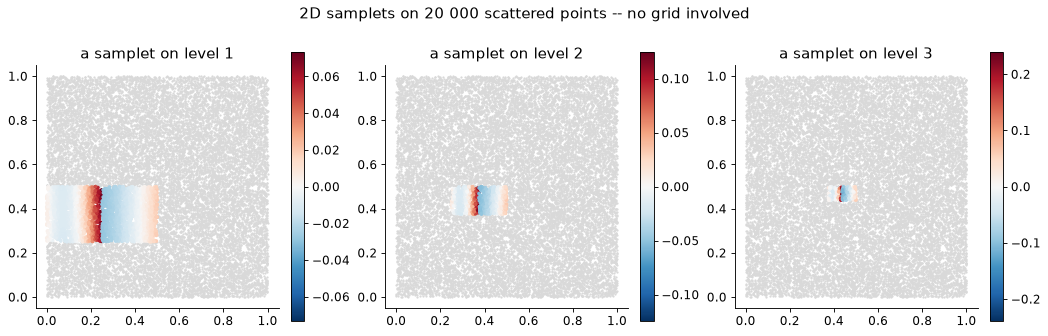

In [25]:
rng = np.random.default_rng(0)
P2 = np.array(rng.random((2, 20000)), order="F")
ST2 = FMCA.SampletTree(P2, 3)
sP2 = np.asfortranarray(P2[:, ST2.indices()])
lvl2 = np.asarray(ST2.levels(), dtype=int)

# in 2D the bounding box diameter does not halve at every split, so only some
# integer levels carry coefficients -- pick three of the levels that do
avail = np.unique(lvl2)
print("levels present:", {int(L): int((lvl2 == L).sum()) for L in avail})
show2 = avail[1:4]

fig, axes = plt.subplots(1, 3, figsize=(13, 4.3))
for ax, L in zip(axes, show2):
    cand = np.where(lvl2 == L)[0]
    ctr = np.array([P2[:, ST2.coeff2indices(j)].mean(axis=1) for j in cand])
    j = cand[np.argmin(np.linalg.norm(ctr - 0.5, axis=1))]
    unit = np.zeros((ST2.npts(), 1), order="F")
    unit[j] = 1.0
    basis = ST2.inverseSampletTransform(unit).ravel()
    supp = np.abs(basis) > 1e-14
    ax.scatter(sP2[0, ~supp], sP2[1, ~supp], s=1, color="0.85")
    s = ax.scatter(sP2[0, supp], sP2[1, supp], s=6, c=basis[supp], cmap="RdBu_r",
                   vmin=-np.abs(basis).max(), vmax=np.abs(basis).max())
    ax.set_title(f"a samplet on level {L}")
    ax.set_aspect("equal")
    ax.grid(False)
    plt.colorbar(s, ax=ax, shrink=0.85)
fig.suptitle("2D samplets on 20 000 scattered points -- no grid involved")
plt.show()